<a href="https://colab.research.google.com/github/deduwkaa/Theory-and-Applications-of-Digital-Signal-Processing/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- ПАРАМЕТРИ ДЛЯ ВАРІАНТУ №13 ---
Несуча частота (f_carrier): 50 + 13 = 63 Гц
Максимальна частота спектру (f_max): 68 Гц
Частота Найквіста (f_nyquist): 136 Гц



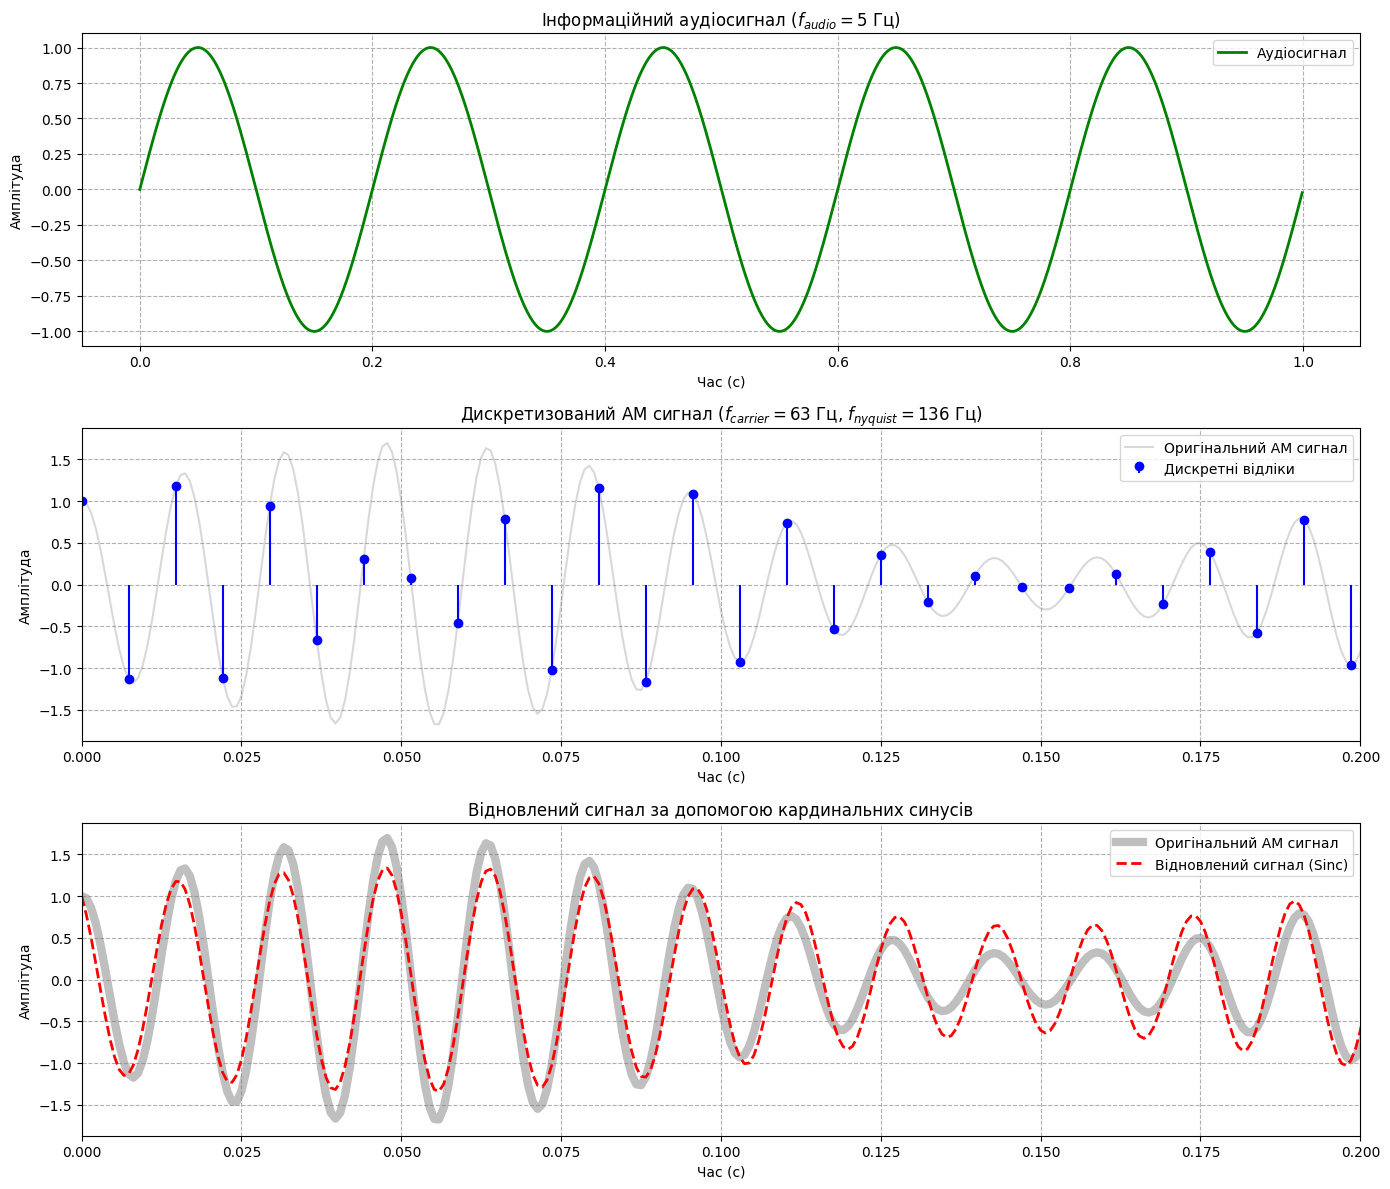

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Вхідні дані
b = 13
A_c = 1
A_m = 1
f_audio = 5
m = 0.7

# Розрахунок несучої частоти за формулою f_carrier = (50 + b)
f_carrier = 50 + b

# Оцінка частоти Найквіста
# Максимальна частота в АМ-сигналі дорівнює сумі несучої та аудіо частоти
f_max = f_carrier + f_audio
# Частота Найквіста має бути вдвічі більшою за максимальну частоту сигналу
f_nyquist = 2 * f_max

print(f"--- ПАРАМЕТРИ ДЛЯ ВАРІАНТУ №{b} ---")
print(f"Несуча частота (f_carrier): 50 + {b} = {f_carrier} Гц")
print(f"Максимальна частота спектру (f_max): {f_max} Гц")
print(f"Частота Найквіста (f_nyquist): {f_nyquist} Гц\n")

# Створюємо масив часу з кроком 1/f_nyquist тривалістю 1 секунда
t_samp = np.arange(0, 1, 1/f_nyquist)

# Генеруємо дискретизований АМ сигнал
audio_samp = A_m * np.sin(2 * np.pi * f_audio * t_samp)
s_am_samp = (1 + m * audio_samp) * A_c * np.cos(2 * np.pi * f_carrier * t_samp)

# За завданням частота вибірки для відновлення: 10 * f_nyquist
f_rec = 10 * f_nyquist
t_rec = np.arange(0, 1, 1/f_rec)

# Ініціалізуємо масив нулями
s_am_rec = np.zeros_like(t_rec)

# Відновлення за допомогою кінцевої суми кардинальних синусів (sinc)
for n, ts in enumerate(t_samp):
    s_am_rec += s_am_samp[n] * np.sinc((t_rec - ts) * f_nyquist)

# Генеруємо ідеальний (оригінальний) сигнал для візуального порівняння
audio_ideal = A_m * np.sin(2 * np.pi * f_audio * t_rec)
s_am_ideal = (1 + m * audio_ideal) * A_c * np.cos(2 * np.pi * f_carrier * t_rec)

# Візуалізація
plt.figure(figsize=(14, 12))

# Графік 1: Аудіосигнал
plt.subplot(3, 1, 1)
plt.plot(t_rec, audio_ideal, 'g', lw=2, label='Аудіосигнал')
plt.title(f'Інформаційний аудіосигнал ($f_{{audio}} = {f_audio}$ Гц)')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.grid(True, linestyle='--')
plt.legend(loc='upper right')

# Графік 2: Дискретизований АМ сигнал
plt.subplot(3, 1, 2)
plt.plot(t_rec, s_am_ideal, 'gray', alpha=0.3, label='Оригінальний АМ сигнал')
plt.stem(t_samp, s_am_samp, linefmt='b-', markerfmt='bo', basefmt=" ", label='Дискретні відліки')
plt.title(f'Дискретизований АМ сигнал ($f_{{carrier}} = {f_carrier}$ Гц, $f_{{nyquist}} = {f_nyquist}$ Гц)')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.xlim(0, 0.2) # Наближаємо, щоб побачити окремі "крапки"
plt.grid(True, linestyle='--')
plt.legend(loc='upper right')

# Графік 3: Відновлений сигнал
plt.subplot(3, 1, 3)
plt.plot(t_rec, s_am_ideal, 'gray', alpha=0.5, lw=6, label='Оригінальний АМ сигнал')
plt.plot(t_rec, s_am_rec, 'r--', lw=2, label='Відновлений сигнал (Sinc)')
plt.title('Відновлений сигнал за допомогою кардинальних синусів')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.xlim(0, 0.2) # Наближаємо для чіткого порівняння
plt.grid(True, linestyle='--')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()